In [1]:
import numpy as np
import yaml
from pathlib import Path
import random
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

In [43]:
def compute_channel_power(data):
    return np.mean(np.abs(data)**2)

def bilinear_channel_estimation(hp_ls):
    """
    # assume a regular grid of pilots
    # assume subcarriers are placed at 0th, 2nd, 4th, ..., 118th indices
    # pilot symbols can be placed at 
        - 2nd
        - 2nd + 3rd
        - 2nd + 7th + 11th
    """
    # 1) interpolate across subcarriers
    pilot_symbol_indices = np.where(hp_ls[0,:].real != 0)[0]
    for pilot_symbol_idx in pilot_symbol_indices:
        for i in range(1, hp_ls.shape[0] - 1, 2):  
            hp_ls[i,pilot_symbol_idx].real = (hp_ls[i-1, pilot_symbol_idx].real + hp_ls[i+1, pilot_symbol_idx].real)/2
            hp_ls[i,pilot_symbol_idx].imag = (hp_ls[i-1, pilot_symbol_idx].imag + hp_ls[i+1, pilot_symbol_idx].imag)/2
        hp_ls[-1,pilot_symbol_idx].real = hp_ls[-2,pilot_symbol_idx].real
        hp_ls[-1,pilot_symbol_idx].imag = hp_ls[-2,pilot_symbol_idx].imag
    
    # 2) interpolate across time or do neirest neighbor assignment
    if len(pilot_symbol_indices) == 1: # 2nd
        pilot_symbol_idx = pilot_symbol_indices[0]
        for i in range(hp_ls.shape[1]):
            if i != pilot_symbol_idx:
                hp_ls[:,i] = hp_ls[:,pilot_symbol_idx]
    elif len(pilot_symbol_indices) == 2: # 2nd and 3rd
        slope = hp_ls[:,3] - hp_ls[:,2]
        for i in range(hp_ls.shape[1]):
            if i < 2:
                hp_ls[:,i] = hp_ls[:,2] - (2 - i)*slope
            elif i > 3:
                hp_ls[:,i] = hp_ls[:,2] + slope*(i - 2)
    elif len(pilot_symbol_indices) == 3: # 2nd, 7th, 11th
        slope_1 = (hp_ls[:,7] - hp_ls[:,2]) / 5
        slope_2 = (hp_ls[:,11] - hp_ls[:,7]) / 4
        for i in range(hp_ls.shape[1]):
            if i < 2:
                hp_ls[:,i] = hp_ls[:,2] - (2 - i)*slope_1
            elif i > 2 and i < 7:
                hp_ls[:,i] = hp_ls[:,2] + slope_1 * (i - 2)
            elif i > 7 and i < 11:
                hp_ls[:,i] = hp_ls[:,7] + slope_2 * (i - 7)
            elif i > 11:
                hp_ls[:,i] = hp_ls[:,11] + slope_2 * (i - 11)
    return hp_ls

In [44]:
class TDLDataset(Dataset):
    def __init__(
        self, data_path, *, file_size, normalization_stats=None,return_pilots_only=True, num_subcarriers=120,
        num_symbols=14, SNRs=[0, 5, 10, 15, 20, 25, 30],
        pilot_symbols=[2, 11], pilot_every_n=2):
        """
        This class loads the data from the folder and returns a dataset of channels.

        data_path: path to the folder containing the data
        file_size: number of channels per file
        return_pilots_only: if True, only the LS channel estimate at pilots are returned
            if False, the LS channel estimate is returned as a sparse channel matrix with non-zero 
            values only at the pilot subcarriers and time instants.
        num_subcarriers: number of subcarriers
        num_symbols: number of OFDM symbols

        SNRs: list of SNR values to randomly sample from when return LS estimates.
            AWGN is added to simulate LS estimatation error
        pilot_symbols: list of OFDM symbol indices where pilots are placed
        pilot_every_n: number of subcarriers between pilot subcarriers
        """
        
        self.file_size = int(file_size)
        self.normalization_stats = normalization_stats
        self.return_pilots_only = return_pilots_only
        self.num_subcarriers = num_subcarriers
        self.num_symbols = num_symbols
        self.SNRs = SNRs
        self.pilot_symbols = pilot_symbols
        self.pilot_every_n = pilot_every_n
        self.noise_variance = self._get_noise_variance(SNRs)

        self.file_list = list(Path(data_path).glob("*.npy"))
        self.stats = self._get_stats_per_file(self.file_list)
        self.data = self._load_data_from_folder(self.file_list, self.normalization_stats)
        self.pilot_mask = self._get_pilot_mask()

        self.num_pilot_symbols = len(self.pilot_symbols)
        self.num_pilot_subcarriers = int(self.pilot_mask.sum()) // self.num_pilot_symbols

    def __len__(self):
        return len(self.file_list) * self.file_size

    def __getitem__(self, idx):
        file_idx = idx // self.file_size
        sample_idx = idx % self.file_size
        file_path = self.file_list[file_idx]
        channels = self.data[file_path]
        channel = channels[sample_idx].squeeze().T

        SNR = random.choice(self.SNRs)
        LS_channel_at_pilots = self._get_LS_estimate_at_pilots(channel, SNR)
        stats = self.stats[file_path]
        stats["SNR"] = SNR

        LS_channel_at_pilots_torch = torch.from_numpy(LS_channel_at_pilots).to(torch.complex64)
        channel_torch = torch.from_numpy(channel).to(torch.complex64)
        return LS_channel_at_pilots_torch, channel_torch, stats
    
    @staticmethod
    def _load_data_from_folder(file_list, normalization_stats=None):
        data = {}
        for file_path in file_list:
            file_data = np.load(file_path)
            if normalization_stats is not None:
                normalized_real = (file_data.real - normalization_stats["real_mean"]) / normalization_stats["real_std"]
                normalized_imag = (file_data.imag - normalization_stats["imag_mean"]) / normalization_stats["imag_std"]
                file_data = normalized_real + 1j * normalized_imag
            data[file_path] = file_data
        return data

    @staticmethod
    def _get_stats_per_file(file_list):
        stats = {}

        for file_path in file_list:
            file_name = str(file_path.stem)
            file_parts = file_name.split("_")

            if file_parts[0] == "delay":
                delay_spread = int(file_parts[2])  # [delay, spread, y, doppler, x]
                doppler_shift = int(file_parts[-1])
            elif file_parts[0] == "doppler":
                doppler_shift = int(file_parts[1])  # [doppler, x, delay, spread, y]
                delay_spread = int(file_parts[-1])
            else:
                raise ValueError(f"File {file_name} has unexpected format")
            
            if file_path not in stats:
                stats[file_path] = {"doppler_shift": doppler_shift, "delay_spread": delay_spread}
            else:
                raise ValueError(f"File {file_path} already in stats, but should not be")
            
        return stats
    
    def _get_noise_variance(self, SNRs):
        noise_variances = []
        for SNR in SNRs:
            noise_variance = 1 / (10**(SNR / 10))
            noise_variances.append(noise_variance)
        return np.mean(np.array(noise_variances))
    
    def _get_LS_estimate_at_pilots(self, channel_matrix, SNR):
        # unit symbol power and unit channel power --> rx noise var = LS error var
        noise_std = np.sqrt(1 / (10**(SNR / 10)))
        noise_real_imag = noise_std / np.sqrt(2)

        if self.return_pilots_only:
            pilot_mask_bool = self.pilot_mask.astype(bool)
            channel_at_pilots = channel_matrix[pilot_mask_bool]
            channel_at_pilots = channel_at_pilots.reshape(self.num_pilot_subcarriers, self.num_pilot_symbols)
            noise_real = noise_real_imag * np.random.randn(self.num_pilot_subcarriers, self.num_pilot_symbols)
            noise_imag = noise_real_imag * np.random.randn(self.num_pilot_subcarriers, self.num_pilot_symbols)
            noise = noise_real + 1j * noise_imag
        else:
            channel_at_pilots = self.pilot_mask * channel_matrix
            noise_real = noise_real_imag * np.random.randn(self.num_subcarriers, self.num_symbols)
            noise_imag = noise_real_imag * np.random.randn(self.num_subcarriers, self.num_symbols)
            noise = noise_real + 1j * noise_imag
            noise = noise * self.pilot_mask
        
        channel_at_pilots_LS = channel_at_pilots + noise
            
        return channel_at_pilots_LS

    def _get_pilot_mask(self):
        pilot_mask = np.zeros((self.num_subcarriers, self.num_symbols))
        pilot_mask_subcarrier_indices = np.arange(0, self.num_subcarriers, self.pilot_every_n)
        pilot_mask[np.ix_(pilot_mask_subcarrier_indices, self.pilot_symbols)] = 1
        return pilot_mask
        

In [45]:
TRAIN_SET_PATH = "/opt/shared/datasets/NeoRadiumTDLdataset/train/TDLA"
TEST_SNR_LEVELS = [100]
LIMIT_CHANNELS = 10000

In [46]:
file_list = list(Path(TRAIN_SET_PATH).glob("*.npy"))

print("There are", len(file_list), "files in the dataset")

channel_power_list = []
for file in file_list:
    channel_power_list.append(compute_channel_power(np.load(file).squeeze()))

avg_channel_power = np.array(channel_power_list).mean()
print("Average channel power:", avg_channel_power)
assert avg_channel_power == 1,  "Channels are not normalized to unit power!"


There are 273 files in the dataset
Average channel power: 1.0


In [47]:
with open(Path(TRAIN_SET_PATH, "metadata.yaml"), "r") as f:
    train_metadata = yaml.safe_load(f)

large_dataset = TDLDataset(
    TRAIN_SET_PATH, 
    file_size=train_metadata["config"]["num_channels_per_config"],
    SNRs=TEST_SNR_LEVELS,
    return_pilots_only=False,
    pilot_symbols=[2, 7, 11])

small_dataset_indices = np.random.choice(len(large_dataset), size=LIMIT_CHANNELS, replace=False)
small_dataset = Subset(large_dataset, small_dataset_indices)

In [48]:
errors = []
channel_powers = []
for hp_ls, h_true, metadata in tqdm(small_dataset):
    h_hat = bilinear_channel_estimation(hp_ls)
    mse = torch.mean(torch.abs(h_hat - h_true)**2)
    channel_power = torch.mean(torch.abs(h_true)**2)
    errors.append(mse/channel_power)
    channel_powers.append(channel_power)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:56<00:00, 176.33it/s]


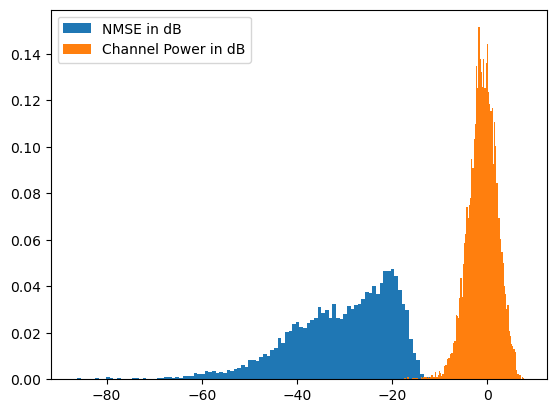

In [ ]:
errors_np = np.array(errors)
channel_powers_np = np.array(channel_powers)

errors_in_db = 10*np.log10(errors_np)
channel_powers_in_db = 10*np.log10(channel_powers_np)

plt.hist(errors_in_db, bins=100, label="NMSE in dB", density=True)
plt.hist(channel_powers_in_db, bins=100, label="Channel Power in dB", density=True)
plt.legend()
plt.show()
